In [1]:
# 🧠 AI Mental Health Sentiment Analyzer
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

nltk.download('stopwords')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load Dataset

data = {
    "text": [
        "I feel happy and motivated today!",
        "Life seems meaningless. I'm so tired of everything.",
        "Had a productive day, feeling great.",
        "I feel so alone and depressed.",
        "Things are getting better. I'm hopeful!",
        "I don't want to talk to anyone.",
        "My anxiety is getting worse.",
        "I love spending time with my family.",
        "I feel confident and at peace.",
        "I can't stop crying."
    ],
    "sentiment": [
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "negative",
        "positive",
        "positive",
        "negative"
    ]
}

df = pd.DataFrame(data)
df.head()


,text,sentiment
0,I feel happy and motivated today!,positive
1,Life seems meaningless. I'm so tired of everyt...,negative
2,"Had a productive day, feeling great.",positive
3,I feel so alone and depressed.,negative
4,Things are getting better. I'm hopeful!,positive


In [3]:
# Preprocess Text Data

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove links
    text = re.sub(r'\@w+|\#','', text)                  # remove mentions/hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\d+', '', text)                     # remove numbers
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

df['clean_text'] = df['text'].apply(clean_text)
df.head()


,text,sentiment,clean_text
0,I feel happy and motivated today!,positive,feel happy motivated today
1,Life seems meaningless. I'm so tired of everyt...,negative,life seems meaningless im tired everything
2,"Had a productive day, feeling great.",positive,productive day feeling great
3,I feel so alone and depressed.,negative,feel alone depressed
4,Things are getting better. I'm hopeful!,positive,things getting better im hopeful


In [5]:
# Split Data

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])


Training size: 8
Testing size: 2


In [6]:
# Convert Text to Numerical Features using TF-IDF

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("✅ TF-IDF vectorization complete!")


✅ TF-IDF vectorization complete!


In [7]:
# Train the Sentiment Model

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

print("✅ Model training complete!")


✅ Model training complete!


Accuracy: 0.0

Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



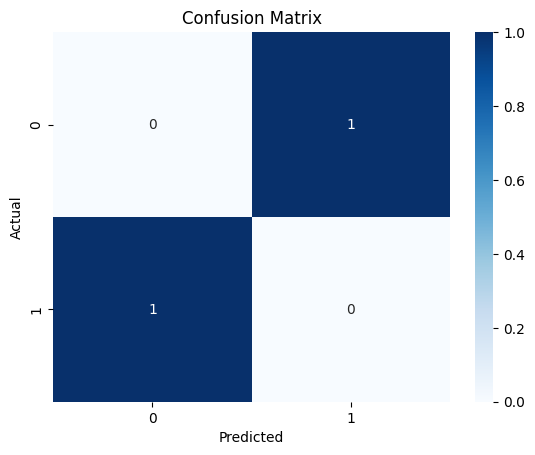

In [8]:
# Evaluate the Model

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [9]:
# Save the Model and Vectorizer

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!


In [10]:
# Test the Model with New Inputs

def predict_sentiment(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return prediction

# Example
sample_text = "I feel so anxious and alone."
print(f"Input: {sample_text}")
print(f"Predicted Sentiment: {predict_sentiment(sample_text)}")


Input: I feel so anxious and alone.
Predicted Sentiment: negative
